# Segment Anything (SAM) — Intro Inference Notebook

This is a first-pass notebook to get SAM running, inspect outputs, and record observations.

###Goal

- Run Segment Anything (SAM)
- Generate segmentation masks for an image
- Understand the basic inference workflow
- Document observations in the context of autonomous vehicle perception systems

###Background

SAM uses a transformer-based architecture consisting of an image encoder and a mask decoder. The image encoder splits an image into patches, embeds them into vectors, applies transformer attention, and produces contextualized image features. The mask decoder combines these image embeddings with optional prompt embeddings (e.g., point clicks, bounding boxes, or mask hints) to predict segmentation masks.

Transformer architectures are well suited for segmentation because they enable global contextual reasoning across the image, helping produce more coherent object boundaries and scene understanding. However, transformers can also be computationally expensive, memory-intensive, and challenging to deploy in real-time systems such as autonomous vehicles.

In addition to prompt-based segmentation, SAM supports automatic mask generation, where the model proposes multiple candidate masks without user guidance. This notebook explores automatic mask generation, a likely requirement for autonomous vehicle perception systems.

## 1. Check GPU


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
device


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


'cuda'

## 2. Install Dependencies

Install SAM from the official GitHub repository.

In [2]:
!pip -q install git+https://github.com/facebookresearch/segment-anything.git
!pip -q install opencv-python matplotlib


  Preparing metadata (setup.py) ... done


## 3. Download a Pretrained SAM Model

Use ViT-B (Vision Transformer Base) as the backbone.


In [3]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
!ls -lh sam_vit_b_01ec64.pth


-rw-r--r-- 1 root root 358M Apr  4  2023 sam_vit_b_01ec64.pth


## 4. Imports and Helper Functions

These helper functions visualize SAM's generated masks.


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


def show_image(image, title="Image", figsize=(8, 8)):
    """Display an RGB image."""
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_anns(anns):
    """Overlay SAM masks on the current matplotlib image."""
    if len(anns) == 0:
        return

    # Overlay largest masks first so smaller masks remain visible on top
    sorted_anns = sorted(anns, key=lambda x: x["area"], reverse=True)
    # Get current plotting area axes
    ax = plt.gca()
    ax.set_autoscale_on(False)

    # Create a tansparent RGBA overlay image
    img = np.zeros((
        sorted_anns[0]["segmentation"].shape[0],
        sorted_anns[0]["segmentation"].shape[1],
        4
    ))

    # For each segmentation mask, set pixels to random color with 0.35 opacity
    for ann in sorted_anns:
        m = ann["segmentation"]
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask

    ax.imshow(img)


def summarize_masks(masks, max_rows=10):
    """Print a compact summary of generated masks."""
    print(f"Number of masks: {len(masks)}")
    print("\nTop masks by area:")

    for i, mask in enumerate(sorted(masks, key=lambda x: x["area"], reverse=True)[:max_rows]):
        print(
            f"{i+1:02d}. area={mask['area']}, "
            f"predicted_iou={mask['predicted_iou']:.3f}, "
            f"stability_score={mask['stability_score']:.3f}"
        )


## 5. Load a Sample Image

Load a free stock street scene image.


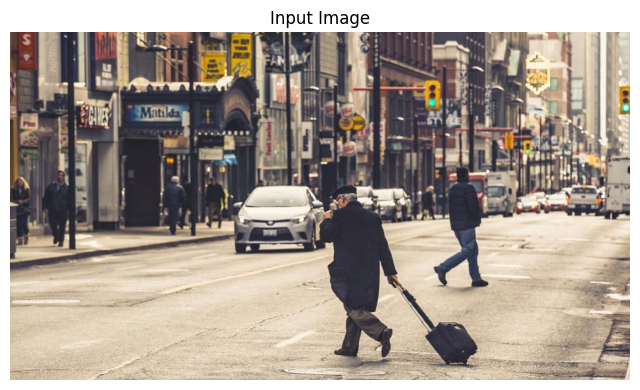

In [5]:
# Public sample image
!wget -q -O sample_image.jpg https://freerangestock.com/sample/168728/urban-street-scene-with-pedestrian-crossing.jpg

# Load image in BGR
image_bgr = cv2.imread("sample_image.jpg")

if image_bgr is None:
    raise FileNotFoundError("Image could not be loaded. Check the image path or download URL.")

# Convert image to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
show_image(image_rgb, title="Input Image")


## 6. Load SAM

In [6]:
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM loaded on", device)


SAM loaded on cuda


## 7. Generate Masks

Use the automatic mask generator to propose many possible object/region masks.

In [23]:
start = time.time()

masks = mask_generator.generate(image_rgb)

end = time.time()

print(f"Inference took {end - start:.2f} seconds")

summarize_masks(masks)


Inference took 4.88 seconds
Number of masks: 110

Top masks by area:
01. area=18264, predicted_iou=0.953, stability_score=0.959
02. area=12650, predicted_iou=0.948, stability_score=0.953
03. area=11653, predicted_iou=0.954, stability_score=0.953
04. area=9575, predicted_iou=0.912, stability_score=0.952
05. area=7309, predicted_iou=0.968, stability_score=0.973
06. area=6648, predicted_iou=0.964, stability_score=0.953
07. area=4788, predicted_iou=0.938, stability_score=0.963
08. area=4065, predicted_iou=0.964, stability_score=0.983
09. area=3774, predicted_iou=0.896, stability_score=0.959
10. area=3584, predicted_iou=0.971, stability_score=0.980


## 8. Visualize Masks

Display an overlay of the regions SAM segmented in the image.


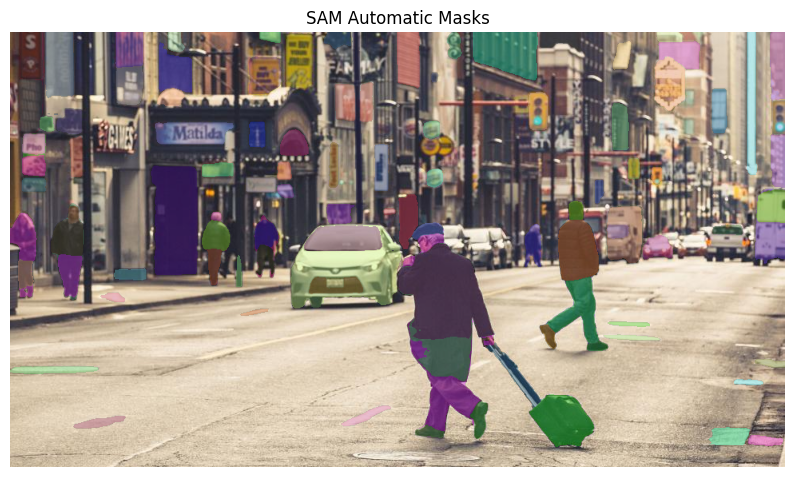

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
show_anns(masks)
plt.axis("off")
plt.title("SAM Automatic Masks")
plt.show()


## 9. Inspect Individual Masks

View individual masks without overlay.


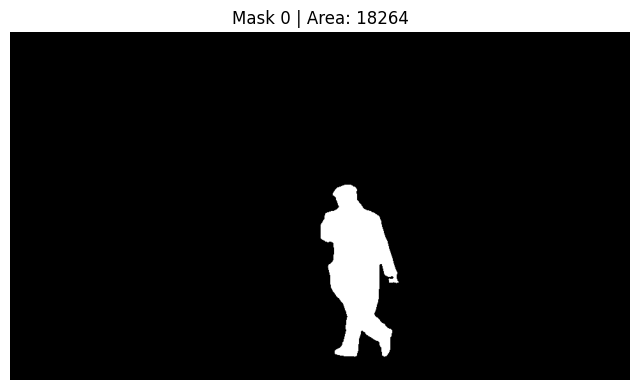

In [20]:
# Sort masks from largest area to smallest
sorted_masks = sorted(masks, key=lambda x: x["area"], reverse=True)

# Change this index to inspect different masks
mask_index = 0
selected = sorted_masks[mask_index]["segmentation"]

plt.figure(figsize=(8, 8))
plt.imshow(selected, cmap="gray")
plt.title(f"Mask {mask_index} | Area: {sorted_masks[mask_index]['area']}")
plt.axis("off")
plt.show()


## 10. Notes

### Observations

- SAM segments large foreground objects more coherently than smaller or distant background objects. This may reflect both the stronger visual prominence of foreground objects and the greater difficulty of segmenting small, low-resolution regions.

- Larger masks often correspond to complete objects or major scene regions, while smaller overlapping masks further decompose objects into subcomponents (e.g., clothing regions within a person). This suggests SAM generates hierarchical or multi-granularity region proposals rather than a single semantic interpretation of the scene.

- Smaller background objects, particularly distant vehicles, were frequently missed or only partially segmented. This could become problematic in autonomous driving contexts where small or distant objects may still be safety-critical.

- Automatic mask generation produced many overlapping masks, indicating that SAM prioritizes broad region proposal coverage over producing a single clean scene decomposition.

- Inference required approximately 4.5–5 seconds on Colab GPU hardware, which is significantly slower than real-time perception requirements for autonomous vehicles.

### Autonomous Vehicle Perception
Autonomous vehicle perception systems further require:
- Processing continous video streams across time
- Low latency, real-time inference
- Object tracking and trajectory prediction
- Semantic understanding of regions (identifying what an object is, not just where it is)
- Integration across the full preception stack, including multi-camera and multi-sensor fusion
- Optimized inference and specialized hardware acceleration
- Operate under limited onboard compute, memory, and power constraints
- High levels of safety, robustness, and reliability
